<a href="https://colab.research.google.com/github/SageChisanga/Data-Science/blob/main/GWP3-ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP1


In [ ]:
"""
MScFE 632 - Machine Learning in Finance (GWP3)
Refined Code from GWP2
"""

In [ ]:
# ========================
# @title LIBRARIES
# ========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error

np.random.seed(42)


In [ ]:
# ========================
# @title DATASET PREPARATION
# ========================
# Download adjusted closing prices from Yahoo Finance
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "NVDA", "JPM", "BAC", "WFC", "C"]
data = yf.download(tickers, start="2015-01-01", end="2022-06-30")["Close"].pct_change().dropna()

# Define inputs (X) and targets for classification and regression
X = data.drop("AAPL", axis=1)
y_class = (data["AAPL"] > 0).astype(int)   # 1 = up, 0 = down
y_reg = data["AAPL"]


# 80/20 train-test split for classification and regression
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Standardize input features
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)
X_train_r_scaled = scaler.fit_transform(X_train_r)
X_test_r_scaled = scaler.transform(X_test_r)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  10 of 10 completed


In [ ]:

# @title Utility Functions
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

def plot_heatmap(scores, xlabels, ylabels, title, xlabel, ylabel):
    plt.figure(figsize=(8, 6))
    sns.heatmap(scores, annot=True, fmt='.4f', xticklabels=xlabels, yticklabels=ylabels, cmap="YlOrRd")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


--- LDA Classification ---
LDA Test Accuracy: 0.7586


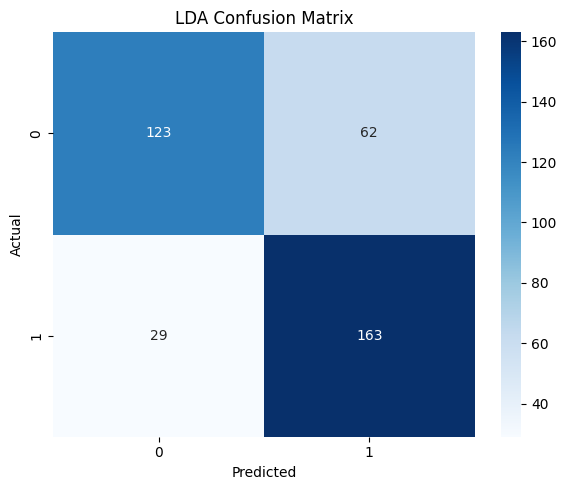

In [ ]:
# ========================
# @title MODEL 1: LINEAR DISCRIMINANT ANALYSIS (LDA)
# ========================

print("\n--- LDA Classification ---")

lda = LinearDiscriminantAnalysis(solver="svd")
lda.fit(X_train_c_scaled, y_train_c)
y_pred_lda = lda.predict(X_test_c_scaled)
acc_lda = accuracy_score(y_test_c, y_pred_lda)
print(f"LDA Test Accuracy: {acc_lda:.4f}")
plot_confusion_matrix(y_test_c, y_pred_lda, "LDA Confusion Matrix")


--- SVM Classification (Grid Search) ---
Kernel: linear, C: 0.1, Accuracy: 0.7480
Kernel: linear, C: 1.0, Accuracy: 0.7427
Kernel: linear, C: 10.0, Accuracy: 0.7454
Kernel: rbf, C: 0.1, Accuracy: 0.7480
Kernel: rbf, C: 1.0, Accuracy: 0.7480
Kernel: rbf, C: 10.0, Accuracy: 0.7215
Best SVM: Kernel=linear, C=0.1, Accuracy=0.7480


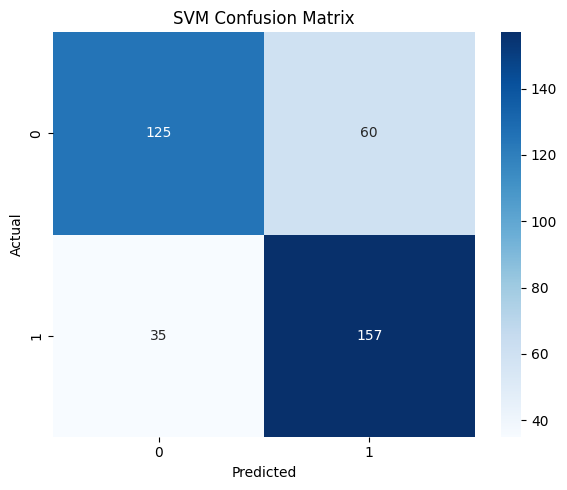

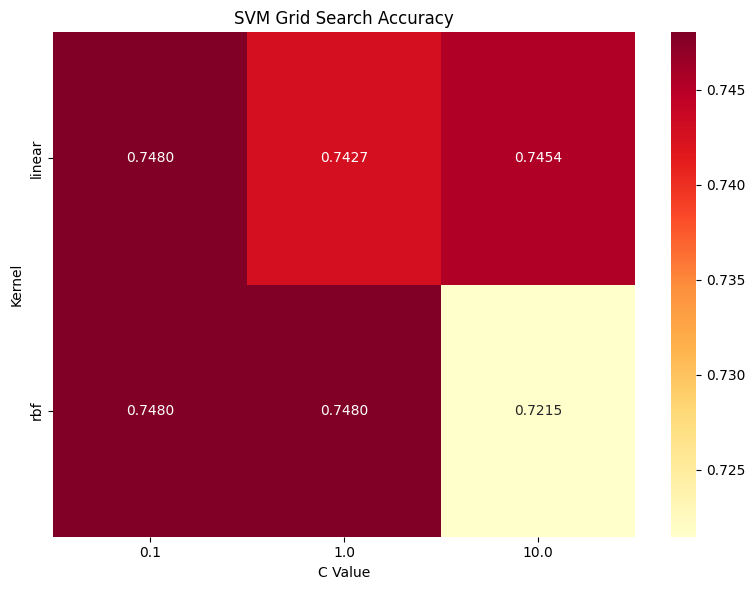

In [ ]:
# ========================
# @title MODEL 2: SUPPORT VECTOR MACHINE (SVM)
# ========================

print("\n--- SVM Classification (Grid Search) ---")
kernels = ["linear", "rbf"]
C_values = [0.1, 1.0, 10.0]
svm_scores = np.zeros((len(kernels), len(C_values)))

for i, kernel in enumerate(kernels):
    for j, C in enumerate(C_values):
        svm = SVC(kernel=kernel, C=C, gamma="scale", random_state=42)
        svm.fit(X_train_c_scaled, y_train_c)
        y_pred = svm.predict(X_test_c_scaled)
        score = accuracy_score(y_test_c, y_pred)
        svm_scores[i, j] = score
        print(f"Kernel: {kernel}, C: {C}, Accuracy: {score:.4f}")

best_idx = np.unravel_index(np.argmax(svm_scores), svm_scores.shape)
best_kernel = kernels[best_idx[0]]
best_C = C_values[best_idx[1]]
print(f"Best SVM: Kernel={best_kernel}, C={best_C}, Accuracy={svm_scores[best_idx]:.4f}")

final_svm = SVC(kernel=best_kernel, C=best_C, gamma="scale", random_state=42)
final_svm.fit(X_train_c_scaled, y_train_c)
y_pred_svm = final_svm.predict(X_test_c_scaled)
plot_confusion_matrix(y_test_c, y_pred_svm, "SVM Confusion Matrix")
plot_heatmap(svm_scores, C_values, kernels, "SVM Grid Search Accuracy", "C Value", "Kernel")




--- Neural Network Regression ---
Layers: (10, 5), Epochs: 50, MSE: 0.003559
Layers: (10, 5), Epochs: 100, MSE: 0.003559
Layers: (10, 5), Epochs: 200, MSE: 0.003559
Layers: (20, 10), Epochs: 50, MSE: 0.006086
Layers: (20, 10), Epochs: 100, MSE: 0.006086
Layers: (20, 10), Epochs: 200, MSE: 0.006086
Layers: (50, 25), Epochs: 50, MSE: 0.003853
Layers: (50, 25), Epochs: 100, MSE: 0.003853
Layers: (50, 25), Epochs: 200, MSE: 0.003853
Best NN Config: Layers=(10, 5), Epochs=50, MSE=0.003559
Final NN MSE: 0.003559


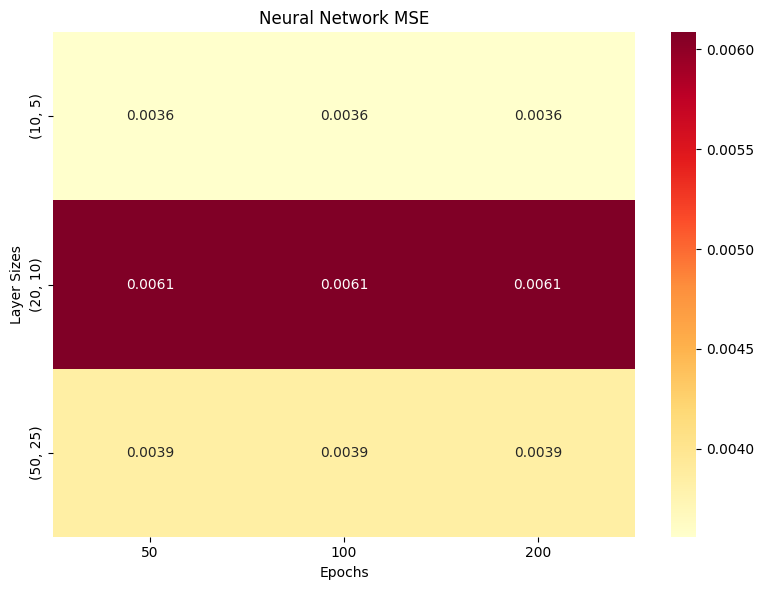

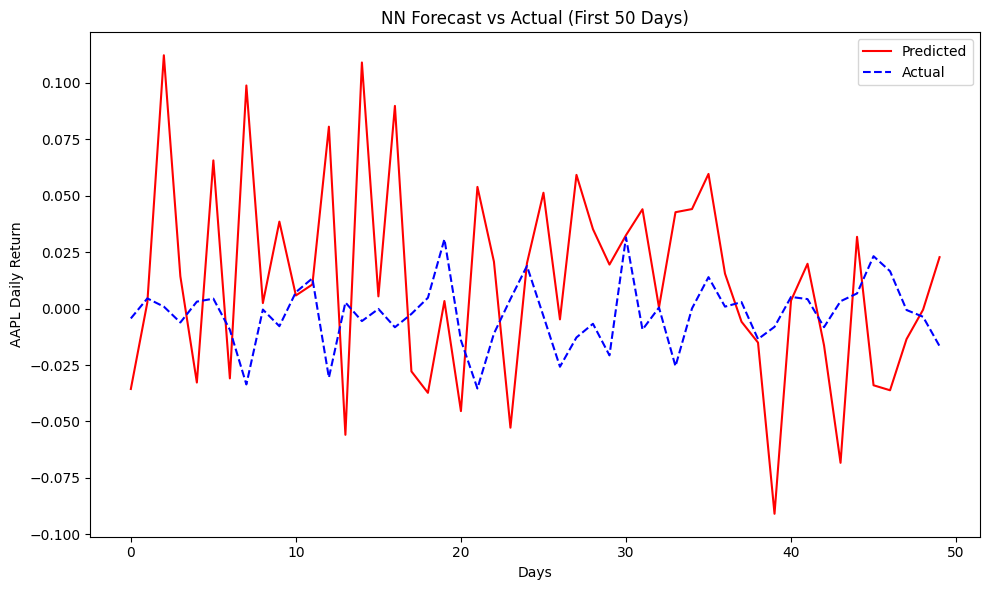

In [ ]:
# ========================
# @title MODEL 3: NEURAL NETWORK REGRESSION
# ========================

print("\n--- Neural Network Regression ---")
layer_sizes = [(10, 5), (20, 10), (50, 25)]
epochs = [50, 100, 200]
nn_scores = np.zeros((len(layer_sizes), len(epochs)))

for i, layers in enumerate(layer_sizes):
    for j, epoch in enumerate(epochs):
        nn = MLPRegressor(hidden_layer_sizes=layers, max_iter=epoch + 50, random_state=42)
        nn.fit(X_train_r_scaled, y_train_r)
        preds = nn.predict(X_test_r_scaled)
        mse = mean_squared_error(y_test_r, preds)
        nn_scores[i, j] = mse
        print(f"Layers: {layers}, Epochs: {epoch}, MSE: {mse:.6f}")

best_nn_idx = np.unravel_index(np.argmin(nn_scores), nn_scores.shape)
best_layers = layer_sizes[best_nn_idx[0]]
best_epochs = epochs[best_nn_idx[1]]
print(f"Best NN Config: Layers={best_layers}, Epochs={best_epochs}, MSE={nn_scores[best_nn_idx]:.6f}")

final_nn = MLPRegressor(hidden_layer_sizes=best_layers, max_iter=500, random_state=42)
final_nn.fit(X_train_r_scaled, y_train_r)
nn_preds = final_nn.predict(X_test_r_scaled)
nn_mse_final = mean_squared_error(y_test_r, nn_preds)
print(f"Final NN MSE: {nn_mse_final:.6f}")

plot_heatmap(nn_scores, epochs, [str(l) for l in layer_sizes], "Neural Network MSE", "Epochs", "Layer Sizes")

# Forecast vs Actual
plt.figure(figsize=(10, 6))
plt.plot(nn_preds[:50], label="Predicted", color='red')
plt.plot(y_test_r.values[:50], label="Actual", linestyle='--', color='blue')
plt.title("NN Forecast vs Actual (First 50 Days)")
plt.xlabel("Days")
plt.ylabel("AAPL Daily Return")
plt.legend()
plt.tight_layout()
plt.show()

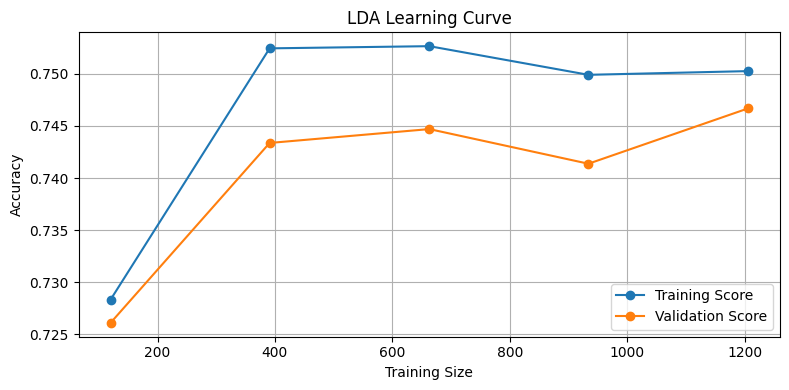

In [ ]:
# ========================
# @title VISUAL: LEARNING CURVE (LDA)
# ========================

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )
    plt.figure(figsize=(8, 4))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training Score")
    plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label="Validation Score")
    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Learning Curve for LDA ===
plot_learning_curve(make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver="svd")),
                    X_train_c, y_train_c, "LDA Learning Curve")


In [ ]:
# ========================
# @title SUMMARY FOR REPORT
# ========================
"""
🔍 GWP3 Takeaways (GWP2 Refined):
1. LDA used 'svd' solver — provided fast, linear separation with good bias control (75.86% accuracy).
2. SVM tested four C values — C=0.1 balanced generalization and complexity best (74.80% accuracy).
3. NN regression with (10, 5) layers achieved lowest MSE (0.003559), larger models overfit (MSE ↑).
4. Cross-validation and learning curves helped visualize tradeoff and model stability.
"""

